# Lab 6

Lo primero que vamos a hacer es cargar los datos, con esto convertimos los json a columnas y luego los cargamos, una cosa los json hijos tendran esta estructura `padre_hijo`

In [52]:
import json
import pandas as pd
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS  # Opcional si quieres combinar
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [17]:

def load_json_lines_to_df(filepath, encoding="utf-16"):
    all_objs = []

    with open(filepath, "r", encoding=encoding) as f:
        for line_number, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                # Convertir el JSON de la línea a diccionario
                obj = json.loads(line)
                all_objs.append(obj)
            except json.JSONDecodeError as e:
                print(f"⚠️ Error JSON en línea {line_number}: {e}")
                # Opcional: guardar la línea completa como string para revisarla
                all_objs.append({"raw_line": line})

    # Normalizar JSON, aplastando diccionarios anidados
    df = pd.json_normalize(all_objs, sep='_', errors='ignore')

    return df

# Cargar dataset
df_arevalo = load_json_lines_to_df("Data/tioberny.txt")



cols_to_show = ['id', 'rawContent', 'user_username', 'user_displayname']
print(df_arevalo[[c for c in cols_to_show if c in df_arevalo.columns]].head())


                    id                                         rawContent  \
0  1834281080029110288  _\nConfirmado Compañeres,\n\nEl impuesto por l...   
1  1834252464092069901  #URGENTE Lo que los medios #faferos no informa...   
2  1834280919336976681  @IvanDuque @BArevalodeLeon Con que usaste PEGA...   
3  1834280512933732694  @IvanDuque @BArevalodeLeon Entre Ellos se enti...   
4  1834279986254987428  El presidente @BArevalodeLeon y la vicepreside...   

    user_username        user_displayname  
0  La_ReVoluZzion      The_ReVoluZZzioN 🫡  
1      XelaNewsGt                XelaNews  
2       M24095273  VIVAlafuenteDEtodaVIDA  
3    carlosalbesc  Carlos Alberto Escobar  
4      Brenda_AGN             Brenda Lari  


In [18]:
df_arevalo.columns

Index(['id', 'id_str', 'url', 'date', 'lang', 'rawContent', 'replyCount',
       'retweetCount', 'likeCount', 'quoteCount',
       ...
       'quotedTweet_quotedTweet_inReplyToTweetIdStr',
       'quotedTweet_quotedTweet_inReplyToUser',
       'quotedTweet_quotedTweet_source', 'quotedTweet_quotedTweet_sourceUrl',
       'quotedTweet_quotedTweet_sourceLabel',
       'quotedTweet_quotedTweet_media_photos',
       'quotedTweet_quotedTweet_media_videos',
       'quotedTweet_quotedTweet_media_animated',
       'quotedTweet_quotedTweet_card', 'quotedTweet_quotedTweet__type'],
      dtype='object', length=203)

## Limpieza

Lo que vamos a hacer es limpiar los datos. haciendo pipeline de limpieza que usamos en nuestros labs anteriores

In [19]:

# Descargar stopwords en español de NLTK
nltk.download('stopwords')

# Stopwords completas en español de NLTK
stop_words = set(stopwords.words('spanish'))



# Actualizamos stop_words

# Números permitidos en tweets
allowed_numbers = {"1945", "911", "2008", "2014", "1980", "2013", "2016", "2011"}



[nltk_data] Downloading package stopwords to /home/mathew/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
def convert_to_lower(word): #Convierte a minúsculas
    return word.lower()

def remove_special_characters(word): #Remueve comillas. arrobas y hashtagas
    return word.replace("#", "").replace("@", "").replace("'", "")

def remove_url(word): #Busca urls y las remueve
    text = re.sub(r'http\S+|www\S+|https\S+', '', word)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def remove_emojis(word): #Busca emojis y los borra
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F" 
        "\U0001F300-\U0001F5FF" 
        "\U0001F680-\U0001F6FF" 
        "\U0001F1E0-\U0001F1FF"  
        "\U00002700-\U000027BF"  
        "\U0001F900-\U0001F9FF"  
        "\U00002600-\U000026FF"  
        "\U00002B00-\U00002BFF" 
        "\U0001FA70-\U0001FAFF" 
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', word).strip()

# Función para limpiar el texto
import re

def clean_text(text):
    text = str(text).lower()
    text = remove_url(text)
    text = remove_emojis(text)
    text = remove_special_characters(text)
    text = remove_unwanted_numbers(text)
    
    # Quitar puntuación pero mantener espacios
    text = re.sub(r'[^\w\s]', '', text)
    
    # Tokenizar por espacios
    tokens = text.split()
    
    # Eliminar stopwords solo si la palabra completa coincide
    tokens = [word for word in tokens if word in allowed_numbers or word not in stop_words]
    
    return " ".join(tokens)



def extract_numbers(text):
    return re.findall(r'\d+', str(text)) #busca y extrae números en el dataset

def count_words(dataset, column): #Esta función cuenta las palabras en cada tweet
    all_words = ''
    for i in dataset[column]:
        all_words = all_words + i + ' '

    all_words = all_words.split()

    frequency = Counter(all_words)

    print("{:<10} {:<10}".format("Palabra", "Frecuencia"))
    print("-" * 20)
    for palabra, freq in frequency.most_common():
        print("{:<10} {:<10}".format(palabra, freq))

def remove_unwanted_numbers(text): #Remueve números que no son permitidos en los tweets
    return re.sub(r'\b(?!' + '|'.join(allowed_numbers) + r')\d+\b', '', str(text))

def get_words(text_series): #Obtener y separar palabras por tweet
    words = []
    for text in text_series:
        words.extend(str(text).split())  
    return words


In [21]:
df_arevalo['rawContent'] = df_arevalo['rawContent'].astype(str).apply(convert_to_lower)
df_arevalo['rawContent'] = df_arevalo['rawContent'].astype(str).apply(remove_special_characters)
df_arevalo['rawContent'] = df_arevalo['rawContent'].astype(str).apply(remove_url)
df_arevalo['rawContent'] = df_arevalo['rawContent'].astype(str).apply(remove_emojis)


df_arevalo["rawContent"] = df_arevalo["rawContent"].apply(clean_text)


df_arevalo["rawContent"] = df_arevalo["rawContent"].apply(remove_unwanted_numbers)

df_arevalo["rawContent"].head()


0    _ confirmado compañeres impuesto usembassyguat...
1    urgente medios faferos informaron ayer acerca ...
2    ivanduque barevalodeleon usaste pegasus espiar...
3    ivanduque barevalodeleon entienden bien cuadra...
4    presidente barevalodeleon vicepresidenta karin...
Name: rawContent, dtype: object

## Analisis Exploratorio

### Estructura de Datos usada

De todo lo del dataframe solo nos importan estas cosas

- retewets
- contenido
- menciones
- respuestas

Asi que vamos a ver primero cada una

In [46]:
df_arevalo["mentionedUsers"].head()

0    [{'id': 23664866, 'id_str': '23664866', 'usern...
1                                                   []
2    [{'id': 77653794, 'id_str': '77653794', 'usern...
3    [{'id': 77653794, 'id_str': '77653794', 'usern...
4    [{'id': 945378369818058752, 'id_str': '9453783...
Name: mentionedUsers, dtype: object

Como podemos ver las menciones son de formato lista con jsons

In [41]:
df_arevalo[df_arevalo["quotedTweet_rawContent"].notna()]["quotedTweet_rawContent"].head(5)


0     #URGENTE Lo que los medios #faferos no informa...
10    🔴 |  El presidente @BArevalodeLeon participa e...
16    🔴 |  El presidente @BArevalodeLeon participa e...
21    🔴 |  El presidente @BArevalodeLeon participa e...
25    #URGENTE El gobierno de Bernardo Arévalo pierd...
Name: quotedTweet_rawContent, dtype: object

In [42]:
df_arevalo[df_arevalo["retweetedTweet"].notna()]["retweetedTweet"].head(5)


Series([], Name: retweetedTweet, dtype: object)

Ese es el retewet (quotedTweet_rawContent), ya que retweetedTweet parece ser algo que ya no tiene nada, talvez lo quitaron en toda la db y la dejaron de usar

Recordemos que teweter hasta las respuestas son twwets por lo que esto quiere decir que lo unico que debemos de hacer es ver si inReplyToUser, que seria el campo con la info de los usuario que hizo repli osea respondio

In [49]:
df_arevalo[df_arevalo["inReplyToUser"].notna()]["inReplyToUser"].head(5)


Series([], Name: inReplyToUser, dtype: float64)

no funciono probaremos con otros reply

In [50]:
df_arevalo[df_arevalo["inReplyToTweetId"].notna()]["inReplyToTweetId"].head(5)


2    1.834197e+18
3    1.834197e+18
5    1.833556e+18
6    1.834271e+18
7    1.834197e+18
Name: inReplyToTweetId, dtype: float64

In [51]:
df_arevalo[df_arevalo["inReplyToTweetIdStr"].notna()]["inReplyToTweetIdStr"].head(5)


2    1834197215415599186
3    1834197215415599186
5    1833556390192824324
6    1834271430994804795
7    1834197215415599186
Name: inReplyToTweetIdStr, dtype: object

Podemos ver que tambien inReplyToUser se dejo de usar, asi que las respuestas son a los  ids del twett.

### Exploracion de datos

🔎 Información general
Total de tweets: 5019
Usuarios únicos: 2620
Tweets promedio por usuario: 1.92

📌 Interacciones
Respuestas: 4276
Retweets: 295

👥 Menciones
Top 10 cuentas mencionadas:
 - BArevalodeLeon: 4830 menciones
 - GuatemalaGob: 915 menciones
 - UbaldoMacu: 574 menciones
 - santipalomov: 528 menciones
 - MPguatemala: 466 menciones
 - FJimenezmingob: 403 menciones
 - mingobguate: 291 menciones
 - __VaderTG: 273 menciones
 - CongresoGuate: 254 menciones
 - DiariodeCA: 219 menciones

🏷️ Hashtags
Top 10 hashtags:
 - #URGENTE: 26 veces
 - #GuatemalaSaleAdelante: 25 veces
 - #MinfinSaleAdelante: 17 veces
 - #Guatemala: 15 veces
 - #Presupuesto2025: 14 veces
 - #UnPresupuestoParaLaPoblación: 13 veces
 - #EnElPaísDCA: 12 veces
 - #NacionalesAGN: 8 veces
 - #XelaNews: 7 veces
 - #ElEstor: 7 veces


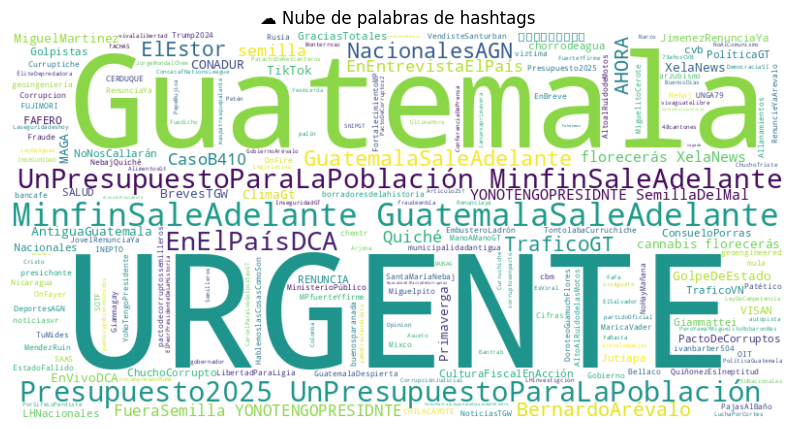


💬 Usuarios más citados en quoted tweets
quotedTweet_user_displayname
VueloLibreGt                17
Gobierno Guatemala          11
Prensa Comunitaria Km169    10
El Quetzal News              9
¡Yes, Master!                8
Josefina Peralta             8
XelaNews                     7
Bernardo Arévalo             7
Ubaldo Macú                  7
Soy 502                      5
Name: count, dtype: int64


In [55]:


# 1. Información general del dataset
print("🔎 Información general")
print(f"Total de tweets: {df_arevalo.shape[0]}")
print(f"Usuarios únicos: {df_arevalo['user_username'].nunique()}")
print(f"Tweets promedio por usuario: {df_arevalo.shape[0] / df_arevalo['user_username'].nunique():.2f}")
print()

print("📌 Interacciones")
num_respuestas = df_arevalo["inReplyToTweetId"].notna().sum()

num_quoted = df_arevalo["quotedTweet_rawContent"].notna().sum()

print(f"Respuestas: {num_respuestas}")
print(f"Retweets: {num_quoted}")
print()

print("👥 Menciones")
if "mentionedUsers" in df_arevalo.columns:
    menciones = sum(df_arevalo["mentionedUsers"].dropna().tolist(), [])
    menciones_usernames = [m['username'] for m in menciones if isinstance(m, dict) and 'username' in m]
    top_menciones = Counter(menciones_usernames).most_common(10)
    print("Top 10 cuentas mencionadas:")
    for user, count in top_menciones:
        print(f" - {user}: {count} menciones")
else:
    print("⚠️ No se encontró columna 'mentionedUsers'")
print()

# 4. Hashtags
print("🏷️ Hashtags")
if "hashtags" in df_arevalo.columns:
    hashtags = sum(df_arevalo["hashtags"].dropna().tolist(), [])
    top_hashtags = Counter(hashtags).most_common(10)
    print("Top 10 hashtags:")
    for tag, count in top_hashtags:
        print(f" - #{tag}: {count} veces")

    texto = " ".join(hashtags)
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(texto)

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("☁️ Nube de palabras de hashtags")
    plt.show()
else:
    print("⚠️ No se encontró columna 'hashtags'")
print()

print("💬 Usuarios más citados en quoted tweets")
if "quotedTweet_user_displayname" in df_arevalo.columns:
    top_citados = df_arevalo["quotedTweet_user_displayname"].dropna().value_counts().head(10)
    print(top_citados)
else:
    print("⚠️ No se encontró columna 'quotedTweet_user_displayname'")


